In [ ]:
import numpy as np
from scipy import signal
from scipy.io import wavfile
from scipy.fft import fftshift
import matplotlib.pyplot as plt
import librosa
from scipy.signal import hilbert, butter, lfilter
import os
import fnmatch

: 

In [206]:
# I got the code from here https://scipy-cookbook.readthedocs.io/items/ButterworthBandpass.html 
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band') # from scipy.signal
    return b, a


def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    #plot_filter(b,a)
    y = lfilter(b, a, data)
    return y

In [207]:
def energy(signal):
    origine = np.sqrt(signal@signal.T/signal.shape[0]) #np.mean(np.abs(signal)) #
    db = librosa.amplitude_to_db(origine)
    return db

In [208]:
def baseline(signal, srate, reference=40):

    assert signal.shape[0] >= int(srate*0.5)

    filtered_signal = butter_bandpass_filter(signal, 4000, 9000, srate, order=6)
    
    db = energy(filtered_signal)

    return db>=reference

### Deciding on the threshold

In [209]:
def values_db (folder_db, exclude_far=False):
    files = os.listdir(folder_db)
    files = [file for file in files if ".wav" in file]

    if exclude_far:
        files = [file for file in files if "100m" not in file]
        files = [file for file in files if "150m" not in file]
        files = [file for file in files if "200m" not in file]

    first_clip = []
    second_clip = []
    third_clip = []

    for song_file in files:
        samplerate, data = wavfile.read(folder_db+song_file)
        data = data.astype(float)

        data = butter_bandpass_filter(data, 4000, 9000, samplerate, order=6)
        
        if data.shape[0] >= 0.5*samplerate:
            clip_one = data[0:int(0.5*samplerate)]
            clip_two = data[int(0.5*samplerate):int(1*samplerate)]
            clip_three = data[int(samplerate):int(1.5*samplerate)]

            first_clip.append(energy(clip_one))
            second_clip.append(energy(clip_two))
            third_clip.append(energy(clip_three))
    return first_clip, second_clip, third_clip, np.concatenate([first_clip, second_clip, third_clip])

/var/folders/zv/_mc0pzhx1n713shby01fv4qc0000gq/T/ipykernel_2521/710197553.py:2: RuntimeWarning: invalid value encountered in scalar divide
  origine = np.sqrt(signal@signal.T/signal.shape[0]) #np.mean(np.abs(signal)) #


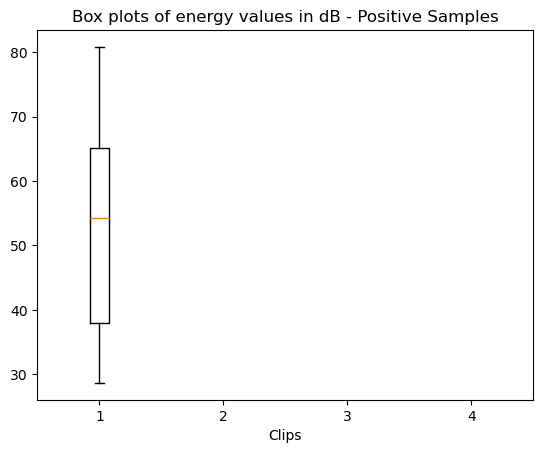

array([65.12729381, 59.9567758 , 60.60477185, ...,         nan,
               nan,         nan])

In [210]:
folder_true = 'YellowHammer/Training_set_YH_songs/positive/'

first_true, second_true, third_true, all_true = values_db (folder_true, exclude_far=False)

plt.boxplot(first_true, positions=[1])
plt.boxplot(second_true, positions=[2])
plt.boxplot(third_true, positions=[3])
plt.boxplot(all_true, positions=[4])

plt.xlabel("Clips")
plt.title("Box plots of energy values in dB - Positive Samples")

plt.show()
#print(np.quantile(all_true, 0.25))
all_true

/var/folders/zv/_mc0pzhx1n713shby01fv4qc0000gq/T/ipykernel_2521/710197553.py:2: RuntimeWarning: invalid value encountered in scalar divide
  origine = np.sqrt(signal@signal.T/signal.shape[0]) #np.mean(np.abs(signal)) #


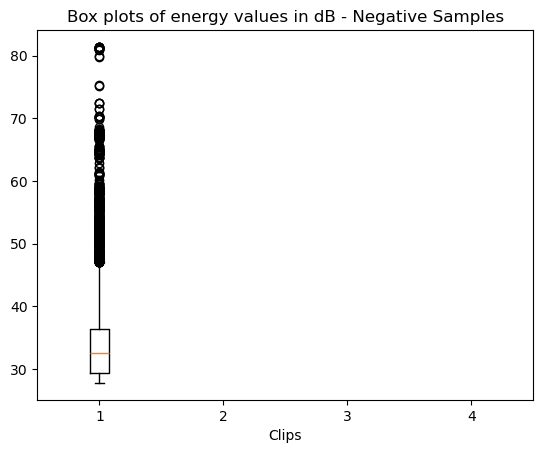

nan


In [211]:
folder_false = 'YellowHammer/Training_set_YH_songs/negative/'

first_false, second_false, third_false, all_false = values_db (folder_false, exclude_far=False)

plt.boxplot(first_false, positions=[1])
plt.boxplot(second_false, positions=[2])
plt.boxplot(third_false, positions=[3])
plt.boxplot(all_false, positions=[4])

plt.xlabel("Clips")
plt.title("Box plots of energy values in dB - Negative Samples")

plt.show()
print(np.quantile(all_false, 0.75))

In [212]:
(np.quantile(all_true, 0.25) + np.quantile(all_false, 0.75))/2

nan

# Get results

In [213]:
DB_THRESHOLD = 38

In [214]:
def predictions_baseline (folder_db, exclude_far=False):
    files = os.listdir(folder_db)
    files = [file for file in files if ".wav" in file]

    if exclude_far:
        files = [file for file in files if "100m" not in file]
        files = [file for file in files if "150m" not in file]
        files = [file for file in files if "200m" not in file]

    first_clip = []
    second_clip = []
    third_clip = []

    for song_file in files:
        samplerate, data = wavfile.read(folder_db+song_file)
        data = data.astype(float)

        data = butter_bandpass_filter(data, 4000, 9000, samplerate, order=6)
        
        if data.shape[0] >= 1.5*samplerate:
            clip_one = data[0:int(0.5*samplerate)]
            clip_two = data[int(0.5*samplerate):int(1*samplerate)]
            clip_three = data[int(samplerate):int(1.5*samplerate)]

            first_clip.append(baseline(clip_one,samplerate, reference=DB_THRESHOLD))
            second_clip.append(baseline(clip_two,samplerate, reference=DB_THRESHOLD))
            third_clip.append(baseline(clip_three,samplerate, reference=DB_THRESHOLD))
    return first_clip, second_clip, third_clip

In [215]:
def postive_rate(check):
    return len([b for b in check if b==True])/len(check)

In [216]:
def results (folder, exclude=False):

    first, second, third = predictions_baseline (folder, exclude_far=exclude)

    PR = np.array([postive_rate(first), postive_rate(second),postive_rate(third)])
    NR = 1 - PR

    all_p = np.concatenate([first, second, third])
    pr_all = postive_rate(all_p)
    all_rates = np.array([pr_all, 1-pr_all])

    return np.round(PR,2),np.round(NR,2), np.round(all_rates,2)

In [217]:
folder_true = 'YellowHammer/Training_set_YH_songs/ALL_Songs_CUT/'

results (folder_true)

(array([0.76, 0.81, 0.8 ]), array([0.24, 0.19, 0.2 ]), array([0.79, 0.21]))

In [218]:
folder_false = 'YellowHammer/Training_set_YH_songs/negative/'
results (folder_false)

ZeroDivisionError: division by zero